# Library Imports
Print python / package info and import libraries

In [1]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam

import json
import datetime
import getpass

# Run config (edit before running)
run_config = {
    "run_id": "branch-name:commit-hash",
    "date_time": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "features_used": ["CDHI","CDNI","DHI","DNI","HOUR","TEMPERATURE"],
    "n_features": 6,
    "scaler": "MinMaxScaler",
    "use_pca": False,
    "pca_n_components": None,
    "learning_rate": globals().get("learning_rate", 0.0005),
    "optimizer": "Adam",
    "loss": "mae",
    "epochs": globals().get("setEpoch", 50),
    "batch_size": globals().get("batch_size", 32),
    "lstm_units": [50, 50],
    "seq_len": globals().get("seq_len", 24),
    "validation_split": 0.1,
    "random_seed": 42,
    "user": getpass.getuser(),
    "cwd": os.getcwd()
}

# Print only the key tuning params to keep output tidy
_tune_keys = ["features_used","n_features","learning_rate","optimizer","loss","epochs","batch_size","lstm_units","seq_len","validation_split","random_seed"]
print("Tuning / run config summary:")
print(json.dumps({k: run_config.get(k) for k in _tune_keys}, indent=2))

# Results record (fill after run)
results = {
    "run_id": run_config["run_id"],
    "training_time_s": None,
    "train_loss": None,
    "val_loss": None,
    "test_MAE": None,
    "test_MSE": None,
    "test_RMSE": None,
    "test_R2": None,
    "model_path": os.path.join(os.getcwd(), "Images", "model_run.h5"),
    "plot_path": os.path.join(os.getcwd(), "Images", "pred_plot.png"),
    "notes": ""
}

def save_run_record(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Results")
    os.makedirs(out_dir, exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(out_dir, f"run_{ts}.json")
    with open(path, "w") as f:
        json.dump({"config": run_config, "results": results}, f, indent=2)
    print("Saved run record to", path)

# Example usage (fill results then call save_run_record)
# results["training_time_s"] = 123.4
# results["test_MAE"] = mae_value
# save_run_record(run_config, results)

print('Python:', sys.version.splitlines()[0])
print('Executable:', sys.executable)
print('cwd:', os.getcwd())
print('Available CSVs:', glob.glob(os.path.join(os.getcwd(), '*.csv')))


Tuning / run config summary:
{
  "features_used": [
    "CDHI",
    "CDNI",
    "DHI",
    "DNI",
    "HOUR",
    "TEMPERATURE"
  ],
  "n_features": 6,
  "learning_rate": 0.0005,
  "optimizer": "Adam",
  "loss": "mae",
  "epochs": 50,
  "batch_size": 32,
  "lstm_units": [
    50,
    50
  ],
  "seq_len": 24,
  "validation_split": 0.1,
  "random_seed": 42
}
Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Executable: c:\Users\nnaji\AppData\Local\Programs\Python\Python313\python.exe
cwd: c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files
Available CSVs: ['c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\BigData.csv', 'c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\MedData.csv', 'c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\SmallData.csv']


## Parameters

In [2]:
learning_rate = 0.0005
setEpoch = 50
batch_size = 32

# explicit data folder and csv
data_dir = r"C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files"
csv_path = os.path.join(data_dir, 'BigData.csv')
assert os.path.isfile(csv_path), f"CSV not found: {csv_path}"
print('Loading dataset:', csv_path)


Loading dataset: C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\BigData.csv


## Load data

In [3]:
df = pd.read_csv(csv_path)
df.head()

,MONTH,DAY,HOUR,MINUTE,TEMPERATURE,WINDANGLE,WINDSPEED,ZENITH,CDHI,CDNI,DHI,DNI,CLOUD,POWER
0,1,1,0,0,10.1,261,4.7,170.95,0,0,0,0,7,0.0
1,1,1,0,30,10.3,261,4.8,168.57,0,0,0,0,6,0.0
2,1,1,1,0,10.4,260,5.0,163.66,0,0,0,0,7,0.0
3,1,1,1,30,10.3,259,4.9,157.84,0,0,0,0,6,0.0
4,1,1,2,0,10.2,258,4.9,151.69,0,0,0,0,6,0.0


## Exploratory plots (compact)
Time-series overview, heatmap and boxplots; remove or reduce these later if too many features.

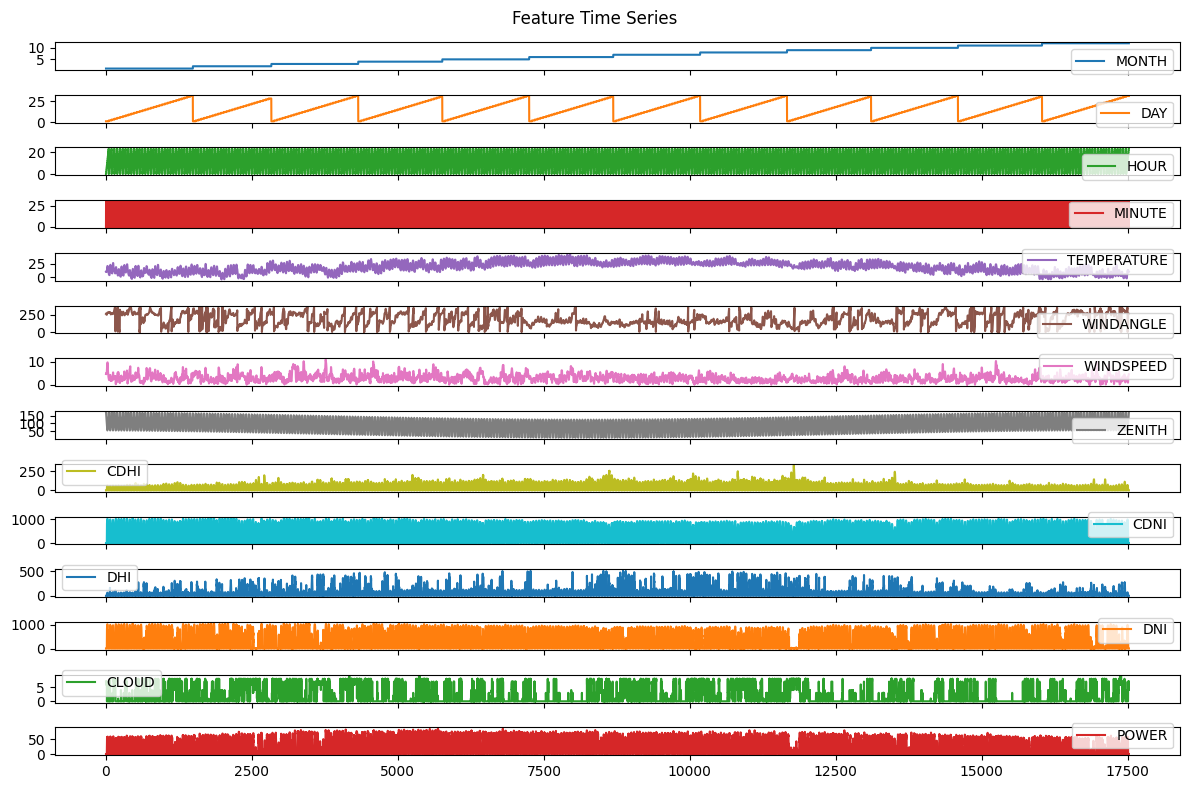

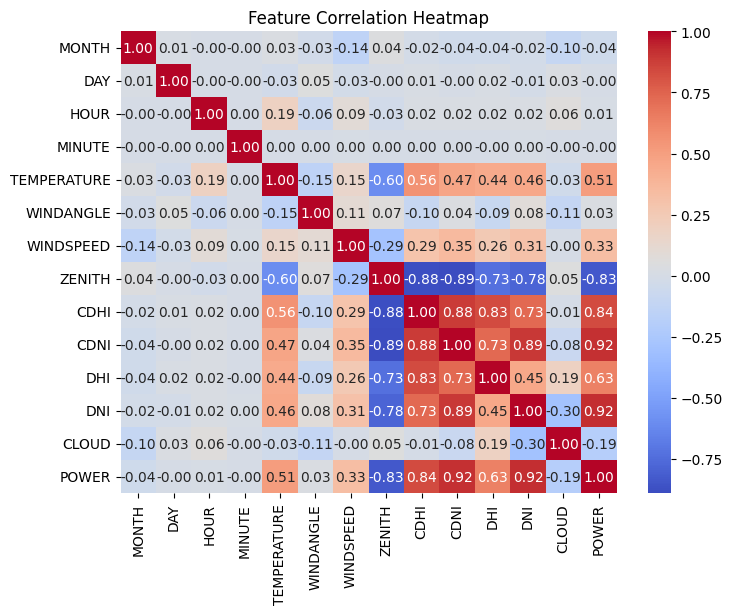

In [4]:
# quick overview: small figure set
df.plot(subplots=True, figsize=(12, 8), title='Feature Time Series')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


## Preprocessing: separate target, reshape, normalize

In [5]:
solar_Xdata = df.copy()
solar_ydata = solar_Xdata.pop('POWER')

# convert to numpy arrays (samples x features) and (samples x 1)
solar_Xdata = solar_Xdata.values.reshape(-1, solar_Xdata.shape[1])
solar_ydata = solar_ydata.values.reshape(-1, 1)

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
solar_XdataN = X_scaler.fit_transform(solar_Xdata)
solar_ydataN = y_scaler.fit_transform(solar_ydata)

print('shapes:', solar_XdataN.shape, solar_ydataN.shape)


shapes: (17520, 13) (17520, 1)


## (Optional) PCA placeholder
Keep this cell for later: apply PCA to solar_XdataN when you create the branch that uses PCA.

In [6]:
# Example (commented) - enable later in PCA branch
# n_components = 3
# pca = PCA(n_components=n_components)
# solar_XdataN_pca = pca.fit_transform(solar_XdataN)
# print('explained variance', pca.explained_variance_ratio_)


## Create sequences for LSTM
Using 24 time steps as in your .py file

In [7]:
seq_len = 24
X, y = [], []
for i in range(seq_len, len(solar_ydataN)):
    X.append(solar_XdataN[i-seq_len:i, :])
    y.append(solar_ydataN[i, 0])
X = np.array(X)
y = np.array(y)
print('X shape:', X.shape)
print('y shape:', y.shape)

# split
train_size = int(0.8 * len(y))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print('train/test sizes:', X_train.shape[0], X_test.shape[0])


X shape: (17496, 24, 13)
y shape: (17496,)
train/test sizes: 13996 3500


## Build and train LSTM model

In [ ]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=50))
model.add(Dense(units=1))

optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mean_absolute_error')

history = model.fit(X_train, y_train, epochs=setEpoch, batch_size=batch_size, validation_split=0.1)
print('Training finished')


Epoch 1/50


c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.1074 - val_loss: 0.0718
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.1074 - val_loss: 0.0718
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0611 - val_loss: 0.0592
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0611 - val_loss: 0.0592
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0530 - val_loss: 0.0532
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0530 - val_loss: 0.0532
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0496 - val_loss: 0.0617
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0496 - val_loss: 0.0617
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0494 - val_loss: 0.0626
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0494 - val_loss: 0.0626
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0465 - val_loss: 0.0420
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step -

## Predict and evaluate

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MAE: 4.91309066486678


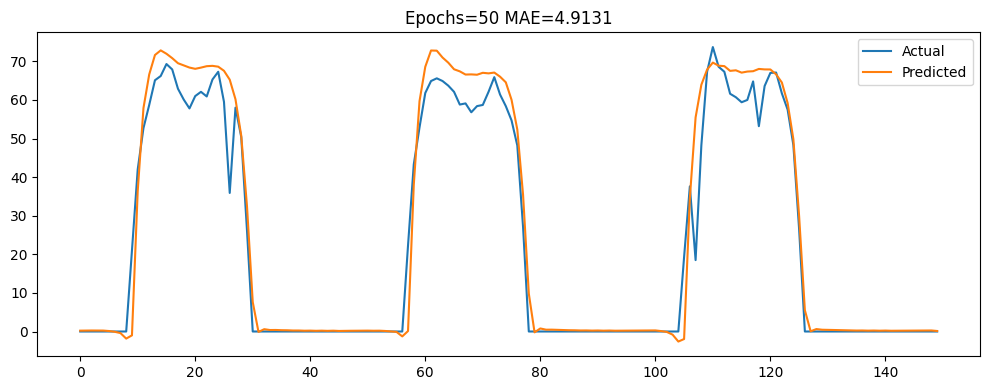

In [ ]:
y_pred = model.predict(X_test)
y_pred_orig = y_scaler.inverse_transform(y_pred)
y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1,1))

mae = mean_absolute_error(y_test_orig, y_pred_orig)
print('MAE:', mae)

# populate results dict with values available now
results["train_loss"] = history.history["loss"][-1] if "history" in globals() and "loss" in history.history else results.get("train_loss")
results["val_loss"] = history.history["val_loss"][-1] if "history" in globals() and "val_loss" in history.history else results.get("val_loss")
results["test_MAE"] = float(mae)
results["model_path"] = results.get("model_path")
results["plot_path"] = results.get("plot_path")

# Print results summary
print("\nRun results summary:")
print(json.dumps(results, indent=2))

# Optionally save run record to Results/ (set run_config['auto_save']=True to enable automatic saving)
if run_config.get("auto_save", False):
    save_run_record(run_config, results)

plt.figure(figsize=(10,4))
plt.plot(y_test_orig[:150], label='Actual')
plt.plot(y_pred_orig[:150], label='Predicted')
plt.legend()
plt.title(f'Epochs={setEpoch} MAE={mae:.4f}')
plt.tight_layout()
plt.show()


## Save model outputs / figures

In [ ]:
out_dir = os.path.join(os.getcwd(), 'Images')
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, f'pred_epoch{setEpoch}_mae{mae:.4f}.png')
plt.figure(figsize=(10,4))
plt.plot(y_test_orig[:150], label='Actual')
plt.plot(y_pred_orig[:150], label='Predicted')
plt.legend()
plt.title(f'Epochs={setEpoch} MAE={mae:.4f}')
plt.tight_layout()
plt.savefig(fig_path)
print('Saved:', fig_path)
plt.close()

Saved: c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\Images\pred_epoch50_mae4.9131.png
